# Task 4 - Churn Prediction Model
**Dataset:** Cleaned Telco Customer Churn (from Task 1)  
Based on insights obtained from exploratory analysis, classification models were developed to predict churn.

Three different models were trained and evaluated. The best-performing model was selected for further analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score, roc_curve)

print("All libraries imported successfully")

All libraries imported successfully


## Step 1: Prepare the Data for ML
In this step, the cleaned dataset was prepared for machine learning.

All categorical variables were encoded to ensure that the dataset contains only numerical values before training the models.

In [2]:
df = pd.read_csv('cleaned_churn_data.csv')
print("Loaded:", df.shape)

# build ML-ready version fresh
df_ml = df.copy()

# drop ID and any segmentation columns from Task 3 if they exist
extra_cols = ['customerID','Tenure_Segment','Charge_Segment','Risk_Score','Risk_Tier']
cols_to_drop = [c for c in extra_cols if c in df_ml.columns]
df_ml.drop(columns=cols_to_drop, inplace=True)

# one-hot encode remaining text columns
df_ml = pd.get_dummies(df_ml, drop_first=True)

# fix bool columns - older sklearn versions don't like True/False
bool_cols = df_ml.select_dtypes(include='bool').columns
df_ml[bool_cols] = df_ml[bool_cols].astype(int)

# safety check
df_ml.fillna(0, inplace=True)

print("ML dataset shape:", df_ml.shape)
print("Missing values:", df_ml.isnull().sum().sum())
print("Any non-numeric:", df_ml.select_dtypes(include='object').shape[1])

Loaded: (7043, 21)
ML dataset shape: (7043, 31)
Missing values: 0
Any non-numeric: 0


## Step 2: Train/Test Split
The dataset was divided into training and testing sets using an 80:20 split.

Stratified sampling was applied to maintain the same class distribution in both sets as in the original dataset.

In [3]:
X = df_ml.drop(columns=['Churn'])
y = df_ml['Churn']

print("Features:", X.shape[1])
print("Target (Churn) distribution:", y.value_counts().to_dict())
print("Churn rate:", round(y.mean()*100, 1), "%")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print()
print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Test churn rate:", round(y_test.mean()*100,1), "% (should match original)")

Features: 30
Target (Churn) distribution: {0: 5174, 1: 1869}
Churn rate: 26.5 %

Train size: 5634
Test size: 1409
Test churn rate: 26.5 % (should match original)


## Step 3: Feature Scaling
Feature scaling was applied before training Logistic Regression to standardize numerical variables.

StandardScaler was fitted on the training data and then applied to the test data to ensure consistent transformation.

In [4]:
scaler = StandardScaler()

# fit ONLY on training data, then transform both
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print("Scaling done.")
print("Sample scaled values (first 3 rows, first 5 features):")
print(X_train_scaled.iloc[:3, :5].round(3))

Scaling done.
Sample scaled values (first 3 rows, first 5 features):
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male
0         -0.442   0.102          -0.522        -0.262        0.994
1         -0.442  -0.712           0.337        -0.504        0.994
2         -0.442  -0.793          -0.809        -0.750        0.994


## Step 4: Train 3 Models
In this step, three classification models were trained and compared:

- Logistic Regression
- Random Forest
- Gradient Boosting

In [5]:
# Logistic Regression  needs scaled data
print("Training Logistic Regression...")
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
print("  done")

# Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("  done")

# Gradient Boosting
print("Training Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42)
gb.fit(X_train, y_train)
print("  done")

print()
print("All 3 models trained successfully")

Training Logistic Regression...
  done
Training Random Forest...
  done
Training Gradient Boosting...
  done

All 3 models trained successfully


## Step 5: Evaluate and Compare Models
Model performance was evaluated using multiple metrics, including accuracy, precision, recall, and F1-score.

Since the objective is to identify customers who are likely to churn, recall was given particular attention during model comparison.

In [6]:
def get_metrics(model, X_in, y_true, name):
    yp = model.predict(X_in)
    yprob = model.predict_proba(X_in)[:, 1]
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_true, yp), 4),
        'Precision': round(precision_score(y_true, yp), 4),
        'Recall': round(recall_score(y_true, yp), 4),
        'F1': round(f1_score(y_true, yp), 4),
        'ROC-AUC': round(roc_auc_score(y_true, yprob), 4)
    }, yp, yprob

results, preds = [], {}
for name, model, X_in in [
    ('Logistic Regression', lr, X_test_scaled),
    ('Random Forest',       rf, X_test),
    ('Gradient Boosting',   gb, X_test)
]:
    m, yp, yprob = get_metrics(model, X_in, y_test, name)
    results.append(m)
    preds[name] = (yp, yprob)
    print(f"{name}: Accuracy={m['Accuracy']} | Recall={m['Recall']} | AUC={m['ROC-AUC']}")

results_df = pd.DataFrame(results).set_index('Model')
print()
print("Full comparison table:")
print(results_df)

Logistic Regression: Accuracy=0.807 | Recall=0.5668 | AUC=0.8418
Random Forest: Accuracy=0.8027 | Recall=0.5 | AUC=0.8445
Gradient Boosting: Accuracy=0.7977 | Recall=0.5267 | AUC=0.8398

Full comparison table:
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.8070     0.6584  0.5668  0.6092   0.8418
Random Forest          0.8027     0.6727  0.5000  0.5736   0.8445
Gradient Boosting      0.7977     0.6459  0.5267  0.5803   0.8398


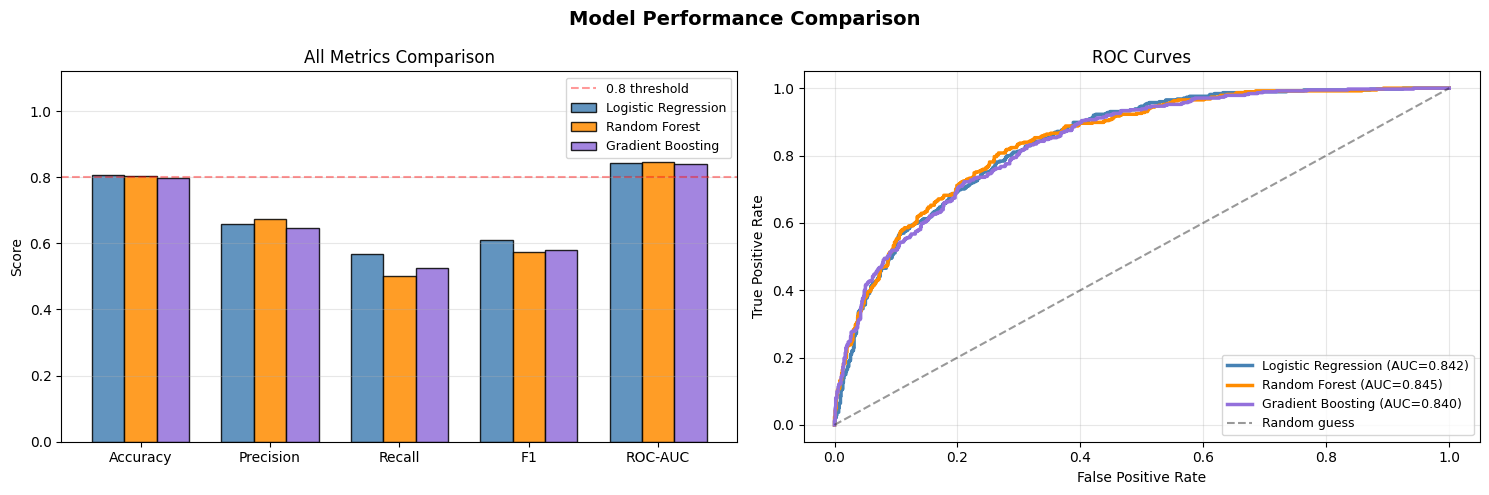

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

model_colors = ['steelblue', 'darkorange', 'mediumpurple']
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metric_cols))
w = 0.25

for i, (mname, color) in enumerate(zip(results_df.index, model_colors)):
    vals = results_df.loc[mname, metric_cols].values.astype(float)
    axes[0].bar(x + (i-1)*w, vals, w, label=mname, color=color, alpha=0.85, edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_cols)
axes[0].set_ylim(0, 1.12)
axes[0].axhline(0.8, color='red', linestyle='--', alpha=0.4, label='0.8 threshold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_title('All Metrics Comparison')
axes[0].set_ylabel('Score')

for (mname, (yp, yprob)), color in zip(preds.items(), model_colors):
    fpr, tpr, _ = roc_curve(y_test, yprob)
    auc = roc_auc_score(y_test, yprob)
    axes[1].plot(fpr, tpr, color=color, lw=2.5, label=f'{mname} (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4, label='Random guess')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ml_01_model_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

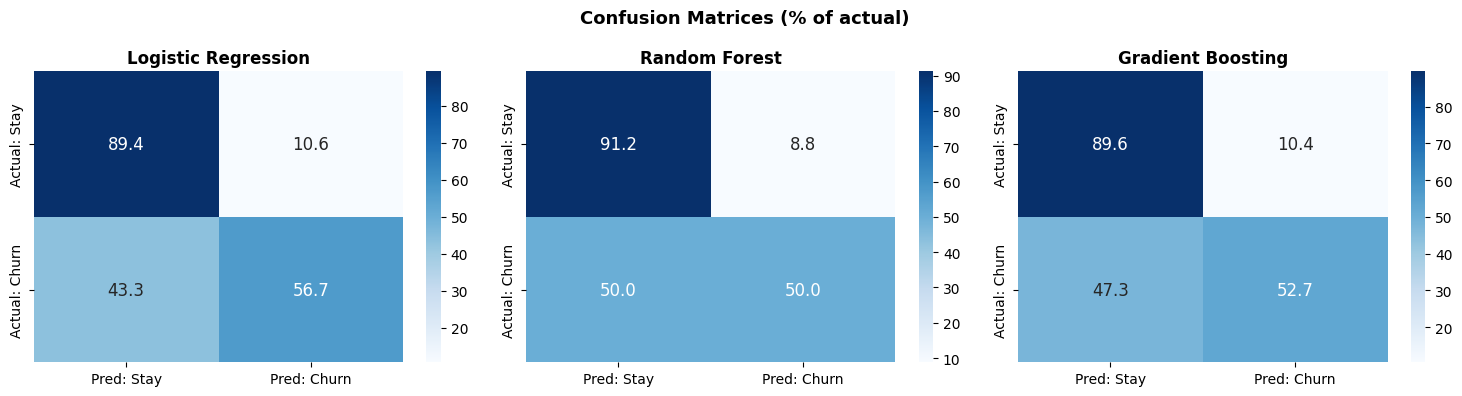

In [8]:
# confusion matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices (% of actual)', fontsize=13, fontweight='bold')

for ax, (mname, (yp, yprob)) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, yp)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
                xticklabels=['Pred: Stay', 'Pred: Churn'],
                yticklabels=['Actual: Stay', 'Actual: Churn'],
                annot_kws={'size':12})
    ax.set_title(mname, fontweight='bold')
plt.tight_layout()
plt.savefig('ml_02_confusion.png', bbox_inches='tight', dpi=120)
plt.show()

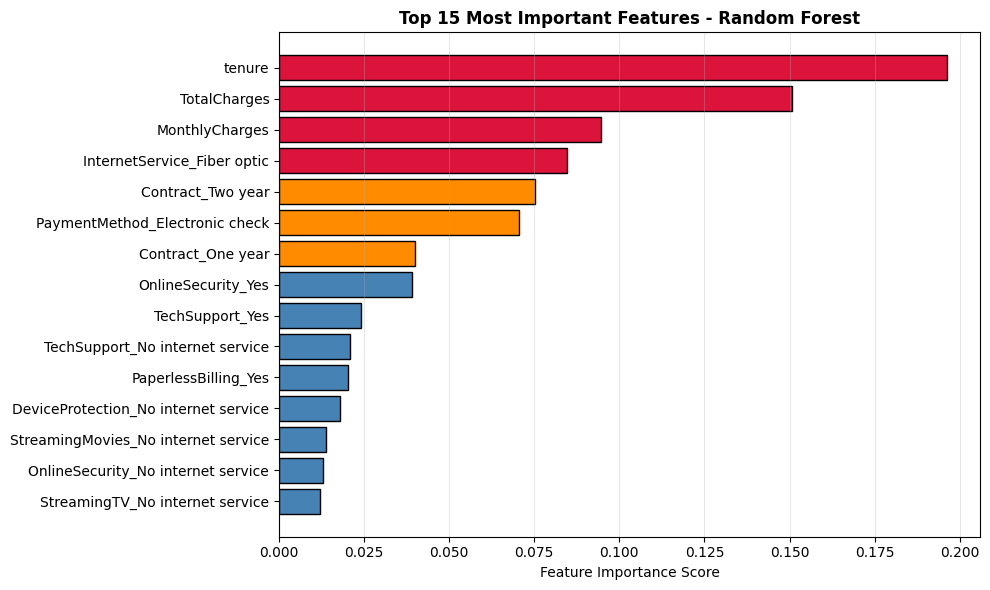

Top 5 most important features:
                    Feature  Importance
                     tenure    0.196151
               TotalCharges    0.150635
             MonthlyCharges    0.094593
InternetService_Fiber optic    0.084754
          Contract_Two year    0.075353


In [9]:
# feature importance from Random Forest
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['crimson' if v > 0.08 else 'darkorange' if v > 0.04 else 'steelblue'
          for v in feat_imp['Importance']]
ax.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1],
        color=colors[::-1], edgecolor='black')
ax.set_xlabel('Feature Importance Score')
ax.set_title('Top 15 Most Important Features - Random Forest', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('ml_03_feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()

print("Top 5 most important features:")
print(feat_imp.head(5).to_string(index=False))

## Section 6: Customer Lifetime Value (LTV) Analysis
In this section, Customer Lifetime Value (LTV) was estimated using predicted churn probabilities from the selected model.

LTV was calculated using the following formula:

LTV = Monthly Charges × Expected Remaining Months × Retention Probability

In [10]:
# using gradient boosting (best model) to predict churn probability for all customers
churn_probs = gb.predict_proba(X)[:, 1]

df_ltv = df.copy()
df_ltv['Churn_Probability'] = churn_probs
df_ltv['Expected_Remaining_Months'] = df_ltv['tenure'].apply(lambda x: max(1, 72 - x))
df_ltv['LTV'] = (df_ltv['MonthlyCharges'] * 
                  df_ltv['Expected_Remaining_Months'] * 
                  (1 - df_ltv['Churn_Probability'])).round(2)

print("LTV calculated for all", len(df_ltv), "customers")
print()
print("LTV Summary:")
print(df_ltv['LTV'].describe().round(1))

LTV calculated for all 7043 customers

LTV Summary:
count    7043.0
mean     1370.1
std       947.3
min        15.6
25%       647.5
50%      1211.1
75%      1996.1
max      5798.1
Name: LTV, dtype: float64


In [11]:
# high-value customers at risk = churn probability > 50% AND LTV above median
ltv_median = df_ltv['LTV'].median()
at_risk = df_ltv[
    (df_ltv['Churn_Probability'] > 0.5) & (df_ltv['LTV'] > ltv_median)
].sort_values('LTV', ascending=False)

print(f"High-value customers at churn risk: {len(at_risk)}")
print(f"Monthly revenue at stake: ${at_risk['MonthlyCharges'].sum():,.0f}")
print(f"Pct of total monthly revenue: {at_risk['MonthlyCharges'].sum()/df_ltv['MonthlyCharges'].sum()*100:.1f}%")
print()
print("Top 10 priority customers to retain:")
print(at_risk[['customerID','MonthlyCharges','tenure','Contract','Churn_Probability','LTV']].head(10).to_string(index=False))

High-value customers at churn risk: 867
Monthly revenue at stake: $71,284
Pct of total monthly revenue: 15.6%

Top 10 priority customers to retain:
customerID  MonthlyCharges  tenure       Contract  Churn_Probability     LTV
2984-AFWNC           95.40       3 Month-to-month           0.523569 3136.15
4566-NECEV           96.55       5 Month-to-month           0.531686 3029.45
4273-MBHYA           89.35       1 Month-to-month           0.523508 3022.80
8413-VONUO           95.65       2 Month-to-month           0.552898 2993.57
8266-VBFQL           90.40       4 Month-to-month           0.514729 2983.06
2344-JMOGN           94.85       9 Month-to-month           0.515838 2893.13
0378-TOVMS           85.80       3 Month-to-month           0.512394 2886.73
3916-NRPAP           85.70       3 Month-to-month           0.516174 2861.01
2252-ISRNH           90.35       9       One year           0.508965 2794.99
8212-DJRCH           90.35       5 Month-to-month           0.539589 2787.07


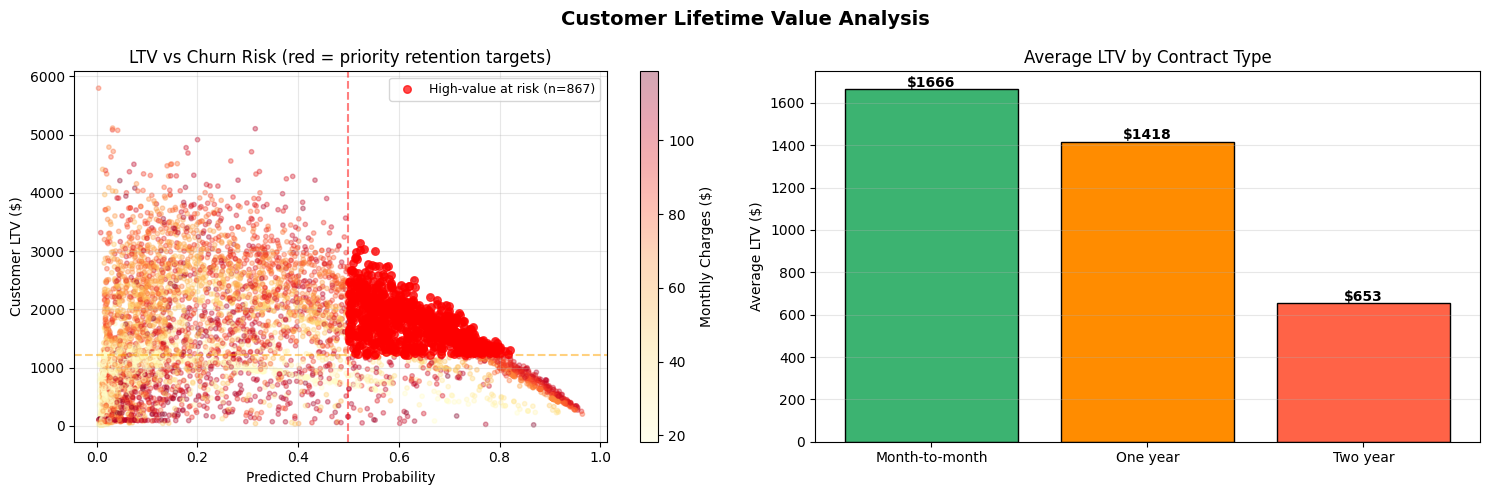

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Customer Lifetime Value Analysis', fontsize=14, fontweight='bold')

sc = axes[0].scatter(df_ltv['Churn_Probability'], df_ltv['LTV'],
                     c=df_ltv['MonthlyCharges'], cmap='YlOrRd', alpha=0.35, s=10)
plt.colorbar(sc, ax=axes[0], label='Monthly Charges ($)')
axes[0].scatter(at_risk['Churn_Probability'], at_risk['LTV'],
                color='red', s=30, alpha=0.7, label=f'High-value at risk (n={len(at_risk)})', zorder=5)
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.5)
axes[0].axhline(ltv_median, color='orange', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Predicted Churn Probability')
axes[0].set_ylabel('Customer LTV ($)')
axes[0].set_title('LTV vs Churn Risk (red = priority retention targets)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

ltv_by_contract = df_ltv.groupby('Contract')['LTV'].mean().sort_values(ascending=False)
bars = axes[1].bar(ltv_by_contract.index, ltv_by_contract.values,
                   color=['mediumseagreen','darkorange','tomato'], edgecolor='black')
for bar, val in zip(bars, ltv_by_contract.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'${val:.0f}', ha='center', fontweight='bold')
axes[1].set_title('Average LTV by Contract Type')
axes[1].set_ylabel('Average LTV ($)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ml_04_ltv_analysis.png', bbox_inches='tight', dpi=120)
plt.show()

In [13]:
# save outputs for Task 5
at_risk.to_csv('high_value_at_risk_customers.csv', index=False)
df_ltv.to_csv('customers_with_ltv_scores.csv', index=False)
print("Files saved.")
print()

best_model = results_df['ROC-AUC'].idxmax()
print("=== Task 4 Summary ===")
print(f"Best model: {best_model} (AUC = {results_df.loc[best_model,'ROC-AUC']})")
print(f"High-value customers at risk: {len(at_risk)}")
print(f"Monthly revenue at stake: ${at_risk['MonthlyCharges'].sum():,.0f}")
print()
print("Task 4 complete!")

Files saved.

=== Task 4 Summary ===
Best model: Random Forest (AUC = 0.8445)
High-value customers at risk: 867
Monthly revenue at stake: $71,284

Task 4 complete!
